In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip


--2025-12-30 05:41:00--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  --.-KB/s    in 0.1s    

2025-12-30 05:41:00 (7.47 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [3]:
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
movies['genres'] = movies['genres'].fillna('')


In [5]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])


In [6]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [7]:
def recommend_movies(movie_title, num_recommendations=5):

    if movie_title not in movies['title'].values:
        print("Movie not found!")
        return

    idx = movies[movies['title'] == movie_title].index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    top_movies = similarity_scores[1:num_recommendations+1]

    print(f"\nTop {num_recommendations} movies similar to '{movie_title}':\n")

    movie_indices = []
    scores = []

    for i, score in top_movies:
        print(movies.iloc[i]['title'], "-> Similarity:", round(score, 3))
        movie_indices.append(i)
        scores.append(score)

    # Visualization
    plt.barh([movies.iloc[i]['title'] for i in movie_indices], scores)
    plt.xlabel("Cosine Similarity")
    plt.title("Movie Recommendations")
    plt.gca().invert_yaxis()
    plt.show()



Top 5 movies similar to 'Toy Story (1995)':

Antz (1998) -> Similarity: 1.0
Toy Story 2 (1999) -> Similarity: 1.0
Adventures of Rocky and Bullwinkle, The (2000) -> Similarity: 1.0
Emperor's New Groove, The (2000) -> Similarity: 1.0
Monsters, Inc. (2001) -> Similarity: 1.0


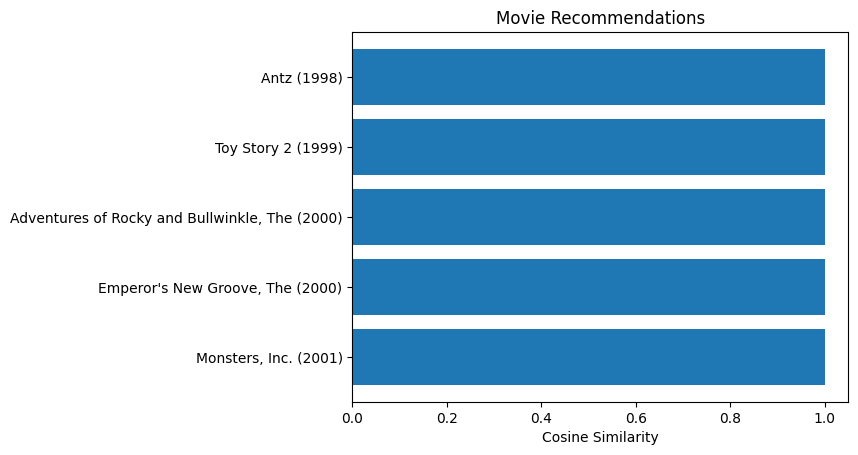

In [8]:
recommend_movies("Toy Story (1995)")
